In [2]:
import importlib
import aaro_draft
import pandas as pd
import matplotlib.pyplot as plt
import Conor
from IPython.display import Image, display
from joblib import Parallel, delayed
import Conor as c


# Reward 1

In [9]:
import importlib
importlib.reload(c)

<module 'Conor' from '/workspaces/Research-Skills-for-Financial-Mathematics/Conor.py'>

In [13]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]
#scalings = [5]
configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -37.516

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -36.138

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -35.069

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -28.059

--- Running: scaling=1 ---
    Done. Final mean VPI: -20.946

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.434

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.717

--- Running: scaling=50 ---
    Done. Final mean VPI: -59.105

--- Running: scaling=100 ---
    Done. Final mean VPI: -100.046

--- Running: scaling=500 ---
    Done. Final mean VPI: -150.259


In [16]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-73801.355520,-37.516390,217.6,217.192
1,0.05,-71803.596410,-36.138323,217.9,217.900
2,0.10,-69925.049527,-35.068703,217.3,217.300
3,0.50,-56891.308985,-28.058881,217.0,217.000
4,1.00,-43910.573702,-20.946483,218.8,218.383
5,5.00,-14029.356646,-3.433636,225.4,223.591
6,10.00,-14033.330646,-3.717209,219.4,216.724
7,50.00,-134848.054889,-59.104781,214.0,213.592
8,100.00,-217129.506648,-100.046304,211.9,210.226
9,500.00,-281269.474885,-150.258506,217.0,217.000


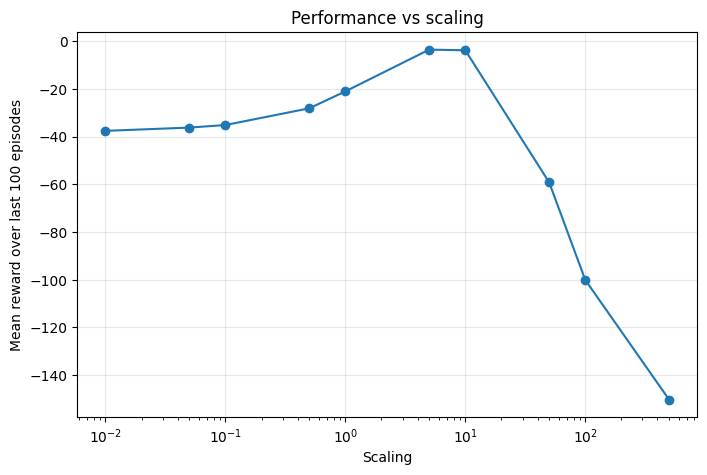

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

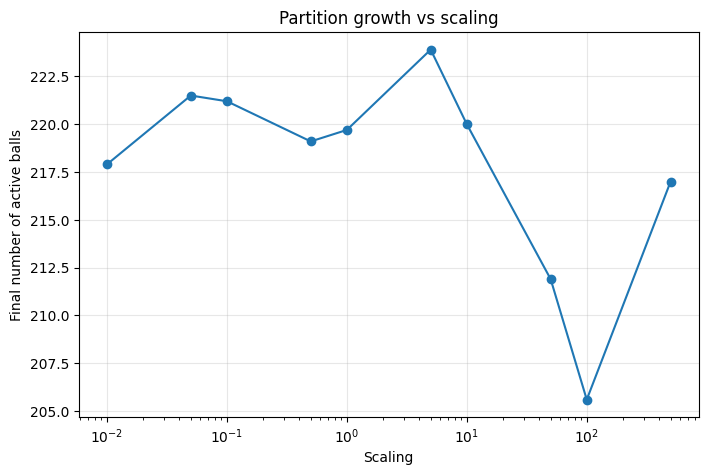

In [39]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

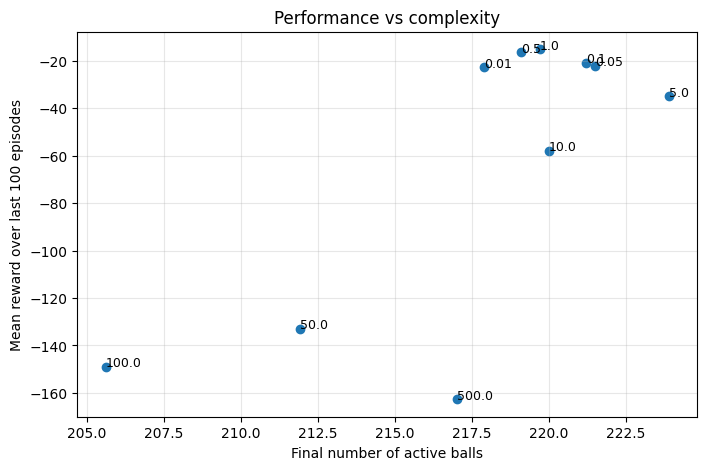

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()


--- Running: scaling=0.1 ---
    Done. Final mean VPI: -20.523

--- Running: scaling=5 ---
    Done. Final mean VPI: -34.718

--- Running: scaling=100 ---
    Done. Final mean VPI: -149.572


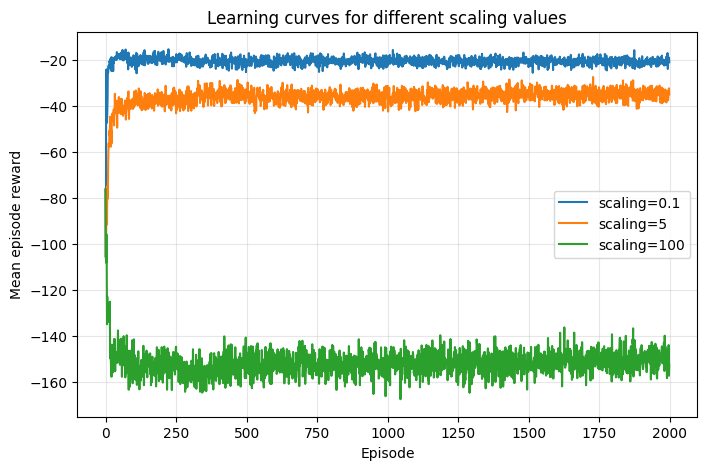

In [41]:
chosen_scalings = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in chosen_scalings
]
results = c.run_experiment(configs, n_jobs=-1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")
plt.title("Learning curves for different scaling values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

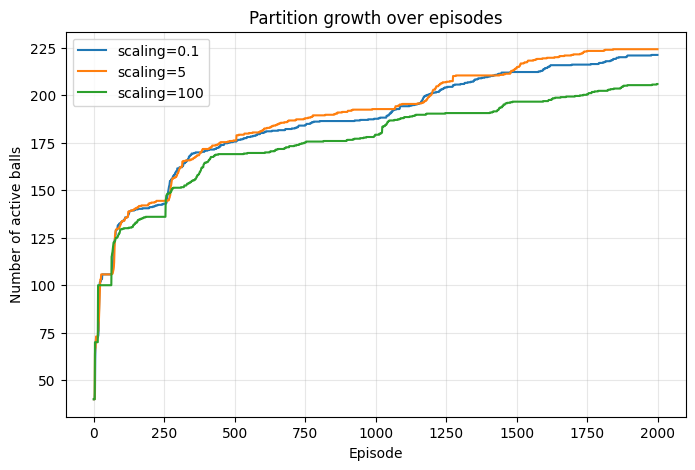

In [42]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["arms"], label=label)

plt.xlabel("Episode")
plt.ylabel("Number of active balls")
plt.title("Partition growth over episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Reward 2


In [43]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -14.873

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -14.318

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -13.101

--- Running: scaling=0.5 ---


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-16591.611676,-8.426018,221.2,219.643
1,0.05,-15208.277622,-7.746110,222.4,220.021
2,0.10,-14731.492843,-7.465462,221.8,220.963
3,0.50,-9574.355877,-4.658924,223.0,220.951
4,1.00,-5439.798541,-2.085139,225.4,224.119
5,5.00,-4364.033131,-1.445654,212.2,211.636
6,10.00,-9763.514760,-3.736471,211.9,207.322
7,50.00,-73796.534267,-33.450325,207.1,206.956
8,100.00,-106308.536977,-52.433119,211.0,211.000
9,500.00,-120332.013242,-63.830951,217.0,217.000


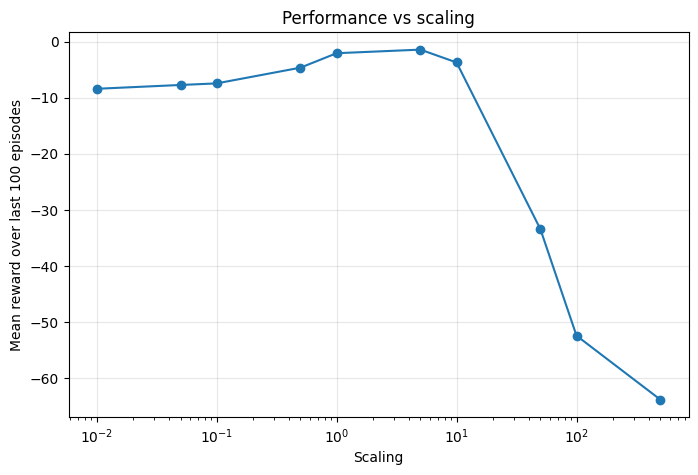

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

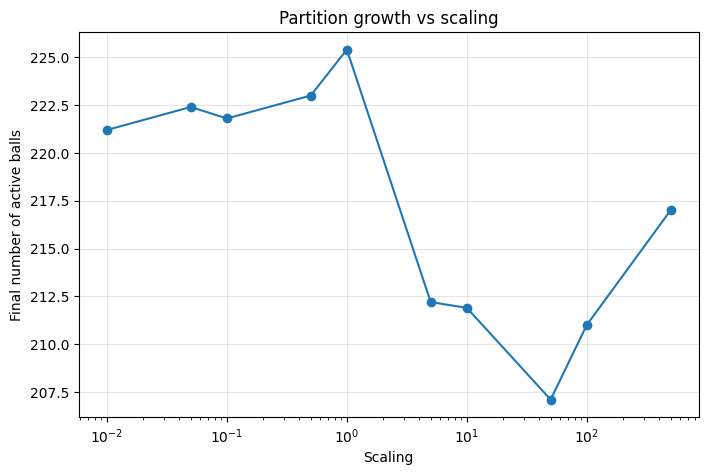

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

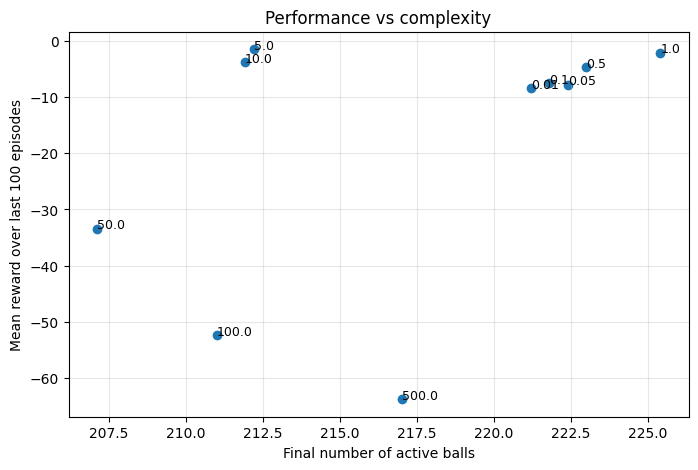

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()


--- Running: scaling=0.1 ---
    Done. Final mean VPI: -7.833

--- Running: scaling=5 ---
    Done. Final mean VPI: -1.479

--- Running: scaling=100 ---
    Done. Final mean VPI: -52.550


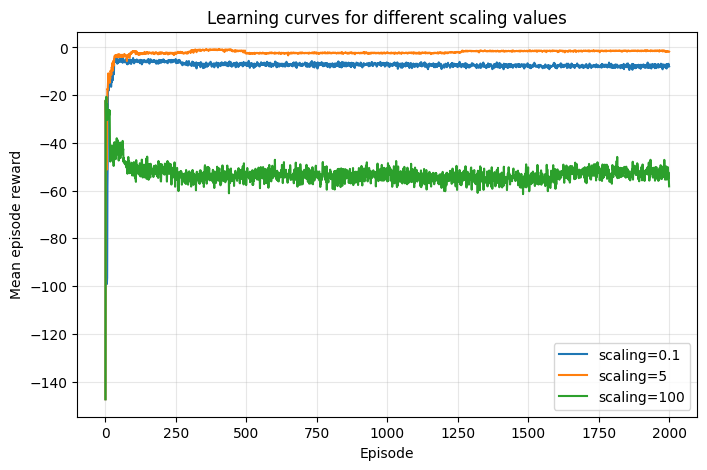

In [ ]:
chosen_scalings = [0.1, 5, 100]



configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in chosen_scalings
]
results = c.run_experiment(configs, n_jobs=-1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")
plt.title("Learning curves for different scaling values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

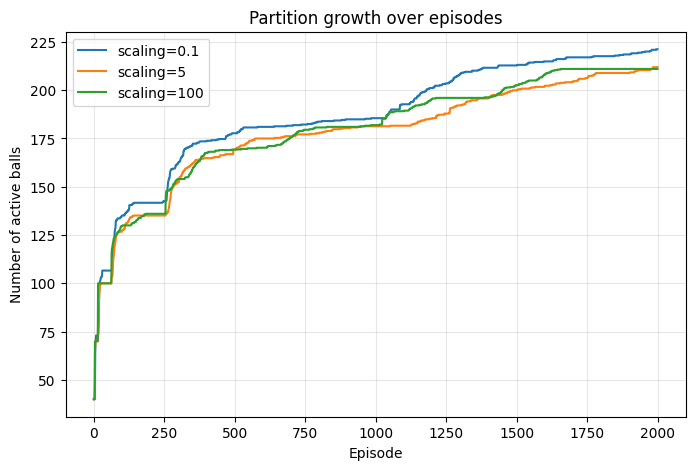

In [ ]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["arms"], label=label)

plt.xlabel("Episode")
plt.ylabel("Number of active balls")
plt.title("Partition growth over episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Reward 3

In [ ]:
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in scalings
]

results = c.run_experiment(configs, n_jobs=-1)


--- Running: scaling=0.01 ---
    Done. Final mean VPI: -42.440

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -42.442

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -43.672

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -36.516

--- Running: scaling=1 ---
    Done. Final mean VPI: -29.546

--- Running: scaling=5 ---
    Done. Final mean VPI: -9.165

--- Running: scaling=10 ---
    Done. Final mean VPI: -5.174

--- Running: scaling=50 ---
    Done. Final mean VPI: -29.150

--- Running: scaling=100 ---
    Done. Final mean VPI: -67.986

--- Running: scaling=500 ---
    Done. Final mean VPI: -212.049


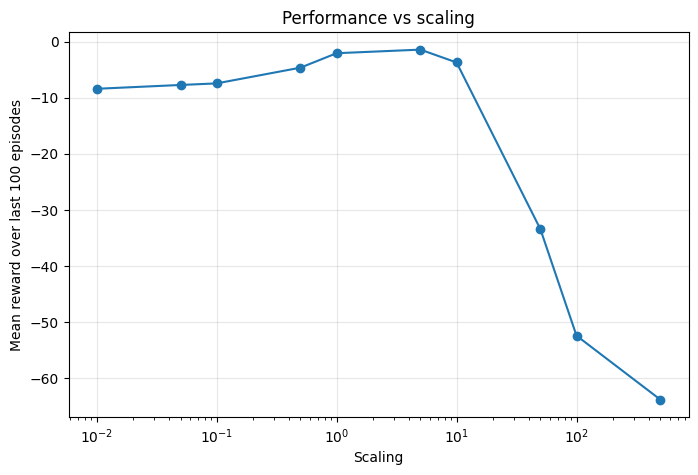

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["late_mean_reward"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

summary = []
for s in scalings:
    label = f"scaling={s}"
    vpi = results[label]["vpi"]
    arms = results[label]["arms"]

    summary.append({
        "scaling": s,
        "final_cum_reward": np.sum(vpi),
        "late_mean_reward": np.mean(vpi[-100:]),
        "final_arms": arms[-1],
        "mean_arms_last100": np.mean(arms[-100:])
    })

summary_df = pd.DataFrame(summary)
summary_df

,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-108196.451402,-42.439836,217.3,217.054
1,0.05,-107835.110941,-42.442218,218.2,218.200
2,0.10,-110187.853505,-43.672145,218.2,218.170
3,0.50,-96276.355493,-36.515674,218.2,218.143
4,1.00,-83581.581826,-29.546391,218.5,217.996
5,5.00,-36907.140728,-9.164529,218.8,217.807
6,10.00,-28325.958628,-5.174181,213.1,211.924
7,50.00,-86723.659749,-29.149654,212.2,212.200
8,100.00,-178837.585244,-67.985618,216.7,216.103
9,500.00,-406207.248573,-212.049255,217.0,217.000


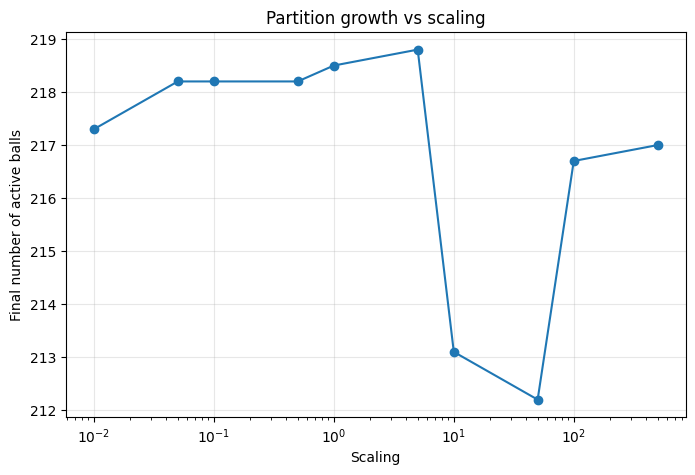

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(summary_df["scaling"], summary_df["final_arms"], marker="o")
plt.xscale("log")
plt.xlabel("Scaling")
plt.ylabel("Final number of active balls")
plt.title("Partition growth vs scaling")
plt.grid(True, alpha=0.3)
plt.show()

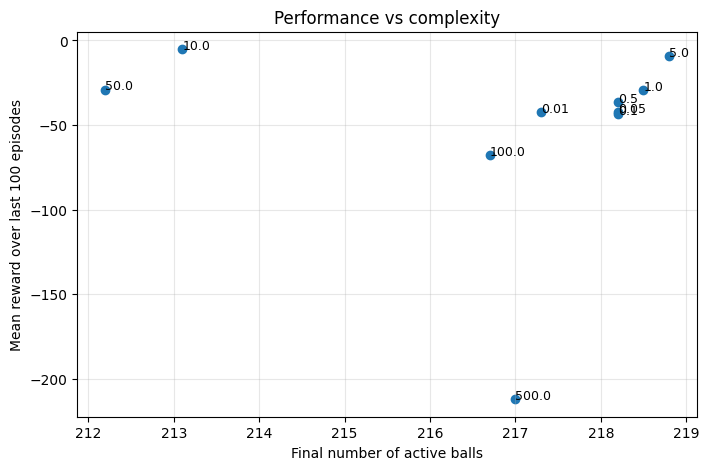

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(summary_df["final_arms"], summary_df["late_mean_reward"])

for _, row in summary_df.iterrows():
    plt.annotate(
        str(row["scaling"]),
        (row["final_arms"], row["late_mean_reward"]),
        fontsize=9
    )

plt.xlabel("Final number of active balls")
plt.ylabel("Mean reward over last 100 episodes")
plt.title("Performance vs complexity")
plt.grid(True, alpha=0.3)
plt.show()


--- Running: scaling=0.1 ---
    Done. Final mean VPI: -41.763

--- Running: scaling=5 ---
    Done. Final mean VPI: -9.310

--- Running: scaling=100 ---
    Done. Final mean VPI: -66.709


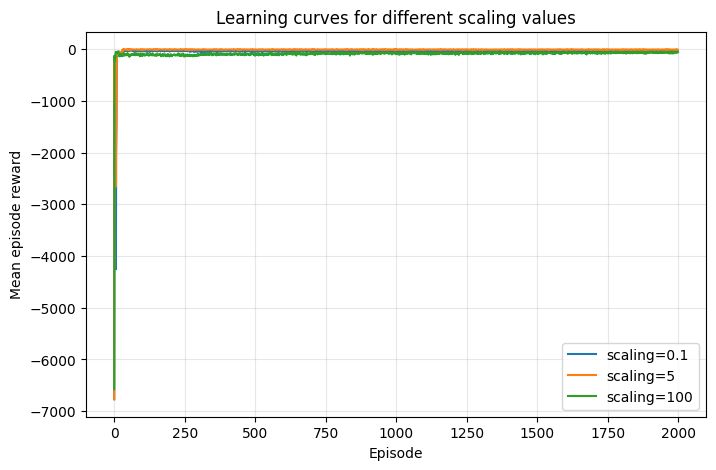

In [ ]:
chosen_scalings = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f"scaling={s}",
        scaling=s,
        alpha=0.5,
        nEps=2000,
        n_seeds=10,
    )
    for s in chosen_scalings
]
results = c.run_experiment(configs, n_jobs=-1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["vpi"], label=label)

plt.xlabel("Episode")
plt.ylabel("Mean episode reward")

plt.title("Learning curves for different scaling values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

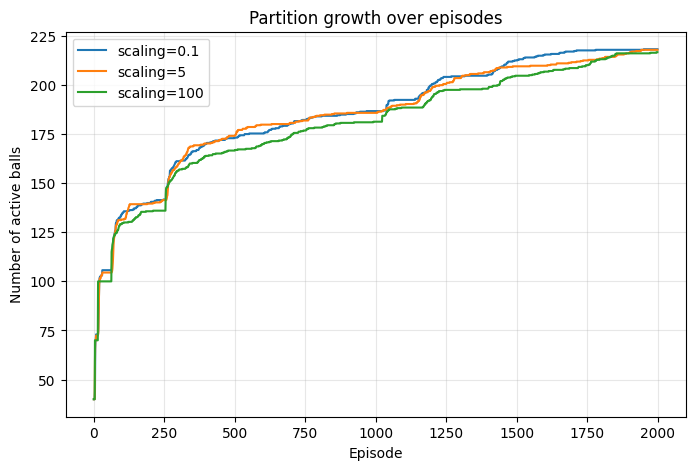

In [ ]:
plt.figure(figsize=(8,5))

for s in chosen_scalings:
    label = f"scaling={s}"
    plt.plot(results[label]["arms"], label=label)

plt.xlabel("Episode")
plt.ylabel("Number of active balls")
plt.title("Partition growth over episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()